# Tennessee Eastman Process — Datensynthese

Erzeugt Trainings-, Test- und Fehlerfalldaten (IDV 13) des angepassten Tennessee Eastman-Prozesses und speichert sie als die Artefakte `data_train`/`data_test`/`data_error` (plus `data_prerun`) im `data_dir`; *tep_model*, *tep_detection* und *tep_adaptation* laden von dort weiter.

Basierend auf Package `pytep`: zugehörige Doku https://github.com/ccreinartz11/pytep. Python ist lediglich Schnittstelle, eigentliche Simulation in Matlab

In [1]:
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, "..", ".."))

base_dir = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
data_dir = base_dir / "data" / "tep"
plot_dir = base_dir / "plots"
results_dir = base_dir / "results"

for _d in (plot_dir, data_dir, results_dir):
    os.makedirs(_d, exist_ok=True)

FORCE_RECOMPUTE = False
IS_FINAL = True  # True: schreibt zusaetzlich den stabilen, eingebundenen Stand; False: nur Archiv
FORCE_PRERUN = False
FORCE_IDV_RECOMPUTE = True

In [2]:
import numpy as np

In [3]:
# --- Konstanten ---
SEED = 42
RAMP_DURATION = 48.0
SOAK_TIME = 96.0 # should be >= ramp duration
TEST_SPLIT = 0.5
BOUNDARY_TOL = 0.1
ERROR_VARIANT_ID = 29
ERROR_VARIANT_AMP = 1.0
T_TOTAL = 4000.0   # h, analog runtime der Testreihe
DRIFT_PERIOD, DRIFT_GAMMA, DRIFT_SEED = 800.0, 0.2, 42   # wie in temexd_mod.c

rng = np.random.default_rng(SEED)

## Rebuild second group of Reinartz et al

In [4]:
import pandas as pd

columns = ["Mode 1", "Mode 2", "Mode 3", "Mode 4", "Mode 5", "Mode 6"]
setpoint_data = {
    "Production":            [22.89, 22.73, 18.04, 36.04, 23.55, 20.2],
    "Stripper level":        [50,    50,    50,    50,    50,    50],
    "Separator level":       [50,    50,    50,    50,    50,    50],
    "Reactor level":         [65,    65,    65,    65,    65,    65],
    "Reactor pressure":      [2800,  2800,  2800,  2800,  2800,  2800],
    f"Mol % G":              [53.8,  11.66, 90.09, 53.35, 11.65, 90.07],
    "yA":                    [63.137,64.196,62.11, 61.94, 64.03, 61.468],
    "yAC":                   [51,    54.24, 47.43, 58.76, 54.32, 48.79],
    "Reactor temperature":   [122.9, 124.2, 121.9, 128.2, 124.6, 123],
    "Recycle valve pos.":    [1,     1,     77.62, 1,     1,     71.166],
    "Steam valve pos.":      [1,     1,     1,     1,     1,     1],
    "Agitator setting":      [100,   100,   100,   100,   100,   100],
}

original_setpoints = pd.DataFrame(setpoint_data)
original_setpoints

,Production,Stripper level,Separator level,Reactor level,Reactor pressure,Mol % G,yA,yAC,Reactor temperature,Recycle valve pos.,Steam valve pos.,Agitator setting
0,22.89,50,50,65,2800,53.80,63.137,51.00,122.9,1.000,1,100
1,22.73,50,50,65,2800,11.66,64.196,54.24,124.2,1.000,1,100
2,18.04,50,50,65,2800,90.09,62.110,47.43,121.9,77.620,1,100
3,36.04,50,50,65,2800,53.35,61.940,58.76,128.2,1.000,1,100
4,23.55,50,50,65,2800,11.65,64.030,54.32,124.6,1.000,1,100
5,20.20,50,50,65,2800,90.07,61.468,48.79,123.0,71.166,1,100


Initialize Simulator 

In [5]:
import pytep.siminterface as siminterface

si = siminterface.SimInterface().setup()

Use index names from pyTEP repo

In [6]:
sp_cols = list(si._setpoint_data.columns)
original_setpoints.columns = sp_cols

Show initial setpoint: should be `Base case` -> `Mode 1` 

In [7]:
[si._matlab_bridge._eng.get_sp_generic(label) for label in sp_cols]

[22.89, 50.0, 50.0, 65.0, 2800.0, 53.8, 63.137, 51.0, 122.9, 1.0, 1.0, 100.0]

Extend Setpoints according to Reinartz et al in a range from -15% to 15% of the original values

In [8]:
MAGNITUDES = np.linspace(-0.15, 0.15, 7)

extended_setpoints = pd.DataFrame()

for mode, values in original_setpoints.iterrows():
    for magnitude in MAGNITUDES:
        original_values = values.copy()
        operation_point = original_values.copy()
        mask = ~(((original_values == 1) & ((original_values * (1 + magnitude)) > 1)) |
             ((original_values == 100) & ((original_values * (1 + magnitude)) > 100)))
        operation_point[mask] = original_values[mask] * (1 + magnitude)
        operation_point.name = f"{mode} / {magnitude:.2f}"
        extended_setpoints = pd.concat([extended_setpoints, operation_point.to_frame().T], axis=0)

extended_setpoints.max(axis=0)

ProductionSP           41.4460
StripLevelSP           57.5000
SepLevelSP             57.5000
ReactorLevelSP         74.7500
ReactorPressSP       3220.0000
MolePctGSP            103.6035
YASP                   73.8254
YACSP                  67.5740
ReactorTempSP         147.4300
RecycleValvePosSP      89.2630
SteamValvePosSP         1.0000
AgitatorSpeedSP       100.0000
dtype: float64

Create DOE from extendex setpoints

In [9]:
from scipy.stats import qmc

n_runs = 300 # Number of experiments

col_min = extended_setpoints.min()
col_max = extended_setpoints.max()

lhs_unit = qmc.LatinHypercube(d=len(extended_setpoints.columns), seed=rng).random(n=n_runs)

scaled = qmc.scale(lhs_unit, col_min.values, col_max.values)

setpoints = pd.DataFrame(scaled, columns=extended_setpoints.columns)

# Round integer-like columns
for col in setpoints.columns:
    if np.allclose(extended_setpoints[col], np.round(extended_setpoints[col])):
        setpoints[col] = np.round(setpoints[col]).astype(int)

Shuffle DOE

In [10]:
shuffled_doe_list = []
for _ in range(10):
    shuffled_indices = rng.permutation(setpoints.index)
    shuffled_doe_list.append(shuffled_indices)

## Simulation

In [11]:
import run_registry as rr

run_cfg = {
    "seed": SEED,
    "n": len(setpoints),
    "ramp_h": RAMP_DURATION,
    "soak_h": SOAK_TIME,
    "test_split": TEST_SPLIT,
}
data_store = rr.tep_data_store(data_dir)
plot_store = rr.tep_plot_store(plot_dir)
cfg = rr.RunConfig(run_cfg)
run_id = cfg.id
print(f"run_id = {run_id}")

run_id = 58a387b8


In [ ]:
# Shutdown-Schranken aus temexd_mod.c (Z. 3279 ff.), umgerechnet auf die
# Einheiten von si._process_data. Volumina dort in ft³ (1 m³ = 35.3145 ft³),
# Fuellstaende als xmeas[7]/[11]/[14] in %.
FT3_PER_M3 = 35.3145
_pct = lambda v_m3, offset, span: (v_m3 * FT3_PER_M3 - offset) / span * 100.0

SHUTDOWN_LIMITS = {                                  # (low, high), isd-Code
    "Reactor Pressure":  (None, 3000.0),                            # isd 1
    "Reactor Level":     (_pct(2.0, 84.6, 666.7), _pct(24.0, 84.6, 666.7)),   # isd 3/2
    "Reactor Temperature": (None, 175.0),                           # isd 4
    "Product Sep Level": (_pct(1.0, 27.5, 290.0), _pct(12.0, 27.5, 290.0)),   # isd 6/5
    "Stripper Level":    (_pct(1.0, 78.25, 156.5), _pct(8.0, 78.25, 156.5)),  # isd 8/7
}

# Betriebsreserve: Warnschwelle bei MARGIN des Abstands Sollwert->Schranke.
LIMIT_MARGIN = 0.75
SETPOINTS_NOM = {"Reactor Pressure": 2800.0, "Reactor Temperature": 122.9,
                 "Reactor Level": 65.0, "Product Sep Level": 50.0,
                 "Stripper Level": 50.0}

def _warn(sp, lo, hi, m=LIMIT_MARGIN):
    return (None if lo is None else sp - m * (sp - lo),
            None if hi is None else sp + m * (hi - sp))

limits = {k: _warn(SETPOINTS_NOM[k], *v) for k, v in SHUTDOWN_LIMITS.items()}
limits

{'Reactor Pressure': 2895,
 'Reactor Level': 100,
 'Reactor Temperature': 150,
 'Product Sep Level': 100,
 'Stripper Level': 100}

In [ ]:
def check_limits(si, limits: dict, *, data=None):
    row = (si._process_data if data is None else data).iloc[-1]
    for key, (lo, hi) in limits.items():
        val = float(row[key])
        if hi is not None and val > hi:
            yield f"    {key} exceeded upper limit {hi:.2f}. Current value: {val:.2f}"
        if lo is not None and val < lo:
            yield f"    {key} fell below lower limit {lo:.2f}. Current value: {val:.2f}"

Pre-run function: find stationary operation points

In [14]:
def find_successful_operation_points(si: siminterface.SimInterface, setpoints: pd.DataFrame, limits: dict):
    successful_operating_points = []

    for idx, setpoint_values in setpoints.iterrows():
        print("Running mode ", idx)
        for label, value in setpoint_values.items():
            si.ramp_setpoint(setpoint_label=label, target_val=float(value), duration=RAMP_DURATION)
        si.simulate(SOAK_TIME)
        print(si._process_data["time"].max(), si._matlab_bridge.get_sim_status())
        violations = list(check_limits(si, limits))
        if si._matlab_bridge.get_sim_status() == "paused" and not violations:
            successful_operating_points.append(idx)
        else:
            for violation in violations:
                print(violation)
        si.reset()
    
    return successful_operating_points

Simulation function

In [15]:
reset_modes = []

if reset_modes:
    print("Reset modes set to: ", reset_modes)

In [16]:
import pandas as pd
from typing import Tuple

def _reset_env(si: siminterface.SimInterface, idv: Tuple[int, float]):
    si.reset()
    if idv is not None:
        si.set_idv(idv_idx=idv[0], value=idv[1])

def _ramp_all(si: siminterface.SimInterface, setpoint_values: pd.DataFrame, duration: float):
    for label, value in setpoint_values.items():
        si.ramp_setpoint(setpoint_label=label, target_val=float(value), duration=duration)

def _collect_step(si: siminterface.SimInterface, idx: int, status: str):
    df = pd.concat(
        [si._process_data, si._manipulated_variables,
         si._setpoint_data, si._cost_data, si._idv_data],
        axis=1,
    )
    df["status"] = status
    df["mode"] = idx
    return df

def _ended_off_grid(ts: float, period: float):
    r = ts % period
    return not (r < BOUNDARY_TOL or r > period - BOUNDARY_TOL)

def run_simulation(
    si: siminterface.SimInterface,
    setpoints: pd.DataFrame,
    ramp_duration: float,
    soak_time: float,
    idv: Tuple[int, float] = None,
    reset_modes: list = None,
    runtime: int = 4000,
):
    reset_modes = reset_modes or []
    mode_list = setpoints.index.to_list()
    period = ramp_duration + soak_time

    _reset_env(si, idv)

    all_data = []
    last_ts = -1.0
    do_reset = False

    for num, (idx, setpoint_values) in enumerate(setpoints.iterrows()):
        next_mode = mode_list[num + 1] if num + 1 < len(mode_list) else None
        if do_reset and reset_modes and idx not in reset_modes:
            print("Skipping mode ", idx, "to reset mode ", next_mode)
            continue

        print("Running mode ", idx)
        _ramp_all(si, setpoint_values, ramp_duration)
        si.simulate(soak_time)

        status = si._matlab_bridge.get_sim_status()
        interim_ts = si._process_data["time"].iloc[-1]
        end_batch = (status == "stopped"
                     or interim_ts + period >= runtime
                     or next_mode in reset_modes)

        if not end_batch:
            _ramp_all(si, original_setpoints.iloc[0], ramp_duration)
            si.simulate(ramp_duration)
            status = si._matlab_bridge.get_sim_status()

        for warning in check_limits(si, limits):
            print("Warning for mode ", idx, ":\n", warning)

        df = _collect_step(si, idx, status)
        all_data.append(df.loc[df["time"] > last_ts].copy())
        last_ts = df["time"].iloc[-1]
        print(" - Last time: ", last_ts, " modulo: ", last_ts % period)

        do_reset = end_batch or _ended_off_grid(last_ts, period)
        if do_reset:
            if status == "stopped":
                print("Simulation stopped prematurely at mode ", idx)
            elif last_ts + period >= runtime:
                print(f"Simulation stopped on purpose before {runtime}h.")
            else:
                print("Simulation stopped on purpose after mode ", idx)
            _reset_env(si, idv)
            last_ts = -1.0

    return pd.concat(all_data, ignore_index=True)

Save reset 

In [17]:
def add_reset(data: pd.DataFrame):
    data["reset"] = False
    data.loc[data["time"].diff()<0, "reset"] = True
    return data

## Load/save prerun data

Prerun for independent testing of all operating points of doe

In [18]:
_prerun_loaded_from_cache = data_store.exists("data_prerun", cfg) and not FORCE_PRERUN
_prerun_loaded_from_cache

True

In [19]:
if _prerun_loaded_from_cache:
    successful_modes = data_store.load("data_prerun", cfg, rename=True)["successful_modes"]
    print(f"Prerun geladen aus Cache ({len(successful_modes)} Modi)")

Prerun geladen aus Cache (56 Modi)


In [20]:
if not _prerun_loaded_from_cache:
    successful_modes = find_successful_operation_points(si, setpoints, limits)
    data_store.save({"meta": run_cfg, "successful_modes": successful_modes}, "data_prerun", cfg)

## Load/save train data

In [21]:
_train_loaded_from_cache = data_store.exists("data_train", cfg) and not FORCE_RECOMPUTE
_train_loaded_from_cache

True

In [22]:
if _train_loaded_from_cache:
    train_data = data_store.load("data_train", cfg, rename=True)
    print(f"Train geladen aus Cache ({len(train_data)} Zeilen)")

Train geladen aus Cache (77761 Zeilen)


First run

In [23]:
if not _train_loaded_from_cache:
    test_share_mode = int(len(successful_modes)*TEST_SPLIT)-1

    train_data = run_simulation(si, setpoints.iloc[successful_modes[:test_share_mode]], RAMP_DURATION, SOAK_TIME)
    train_data["original_index"] = train_data.index
    train_data = add_reset(train_data)
    train_data.attrs = run_cfg

    data_store.save(train_data, "data_train", cfg)

Second run

In [24]:
if not _train_loaded_from_cache:
    mode_final_status = train_data.groupby("mode")["status"].last()
    bad_modes = mode_final_status[mode_final_status == "stopped"].index
    successful_modes = pd.Index([m for m in successful_modes if m not in bad_modes])

    test_share_mode = int(len(successful_modes)*TEST_SPLIT)-1

    train_data = run_simulation(si, setpoints.iloc[successful_modes[:test_share_mode]], RAMP_DURATION, SOAK_TIME)
    train_data["original_index"] = train_data.index
    train_data = add_reset(train_data)
    train_data.attrs = run_cfg

    data_store.save(train_data, "data_train", cfg)
    data_store.save({"meta": run_cfg, "successful_modes": successful_modes}, "data_prerun", cfg)

In [25]:
print("Successful training modes: ", len(successful_modes))

Successful training modes:  56


## Load/save test data

In [26]:
_test_loaded_from_cache = data_store.exists("data_test", cfg) and not FORCE_RECOMPUTE
_test_loaded_from_cache

True

In [27]:
if _test_loaded_from_cache:
    test_data = data_store.load("data_test", cfg, rename=True)
    print(f"Test geladen aus Cache ({len(test_data)} Zeilen)")

Test geladen aus Cache (79681 Zeilen)


First run

In [28]:
if not _test_loaded_from_cache:
    test_share_mode = int(len(successful_modes)*TEST_SPLIT)-1

    test_data = run_simulation(si, setpoints.iloc[successful_modes[test_share_mode:]], RAMP_DURATION, SOAK_TIME)
    test_data["original_index"] = test_data.index
    test_data = add_reset(test_data)
    test_data.attrs = run_cfg

    data_store.save(test_data, "data_test", cfg)

Second run

In [29]:
manual_bad_modes = []

In [30]:
if not _test_loaded_from_cache:
    mode_final_status = test_data.groupby("mode")["status"].last()
    bad_modes = mode_final_status[mode_final_status == "stopped"].index
    bad_modes = bad_modes.union(pd.Index(manual_bad_modes))
    successful_modes = pd.Index([m for m in successful_modes if m not in bad_modes])

    test_share_mode = int(len(successful_modes)*TEST_SPLIT)-1

    test_data = run_simulation(si, setpoints.iloc[successful_modes[test_share_mode:]], RAMP_DURATION, SOAK_TIME)
    test_data["original_index"] = test_data.index
    test_data = add_reset(test_data)
    test_data.attrs = run_cfg

    data_store.save(test_data, "data_test", cfg)

## Load/save error data

In [31]:
error_variant = {"idv": ERROR_VARIANT_ID, "amp": ERROR_VARIANT_AMP}
error_cfg = cfg.compose(error=error_variant)
print(f"error_run_id = {error_cfg.id} (Rohdaten {error_cfg.base_id})")


_error_loaded_from_cache = data_store.exists("data_error", error_cfg) and not FORCE_RECOMPUTE and not FORCE_IDV_RECOMPUTE
_error_loaded_from_cache

error_run_id = fedcacf7 (Rohdaten 58a387b8)


False

In [32]:
if _error_loaded_from_cache:
    error_data = data_store.load("data_error", error_cfg, rename=True)

Simulator neu aufsetzen, damit der Fehlerfall aus definiertem Zustand startet

In [33]:
if not _error_loaded_from_cache:
    si._matlab_bridge.stop_engine()
    si = siminterface.SimInterface().setup()

In [34]:
if not _error_loaded_from_cache:
    successful_test_modes = test_data["mode"].unique().tolist()
    reset_modes = test_data.loc[test_data["reset"]==True, "mode"].to_list()
    error_data = run_simulation(si, setpoints.iloc[successful_test_modes], RAMP_DURATION, SOAK_TIME, idv=(ERROR_VARIANT_ID, ERROR_VARIANT_AMP), reset_modes=reset_modes)
    error_data["original_index"] = error_data.index
    error_data = add_reset(error_data)
    error_data.attrs = run_cfg

    data_store.save(error_data, "data_error", error_cfg)

Running mode  139
 - Last time:  144.0  modulo:  0.0
Running mode  147
 - Last time:  288.0  modulo:  0.0
Running mode  154
 - Last time:  432.0  modulo:  0.0
Running mode  155
 - Last time:  576.0  modulo:  0.0
Running mode  165
 - Last time:  720.0  modulo:  0.0
Running mode  167
Warning for mode  167 :
     Reactor Pressure exceeded limit of 2895. Current value: 3000.000419623561
 - Last time:  763.8000000000001  modulo:  43.80000000000007
Simulation stopped prematurely at mode  167
Running mode  171
 - Last time:  144.0  modulo:  0.0
Running mode  191
 - Last time:  287.9999999999941  modulo:  143.9999999999941
Running mode  195
 - Last time:  432.0  modulo:  0.0
Running mode  196
 - Last time:  576.0  modulo:  0.0
Running mode  198
Warning for mode  198 :
     Reactor Pressure exceeded limit of 2895. Current value: 2999.8795674583475
 - Last time:  666.5500000000001  modulo:  90.55000000000007
Simulation stopped prematurely at mode  198
Running mode  204
 - Last time:  144.0  modu

Select n most influenced parameters

In [35]:
n = 5
num_cols = train_data.select_dtypes(include="number").columns
candidates = [c for c in num_cols if c not in ["time", "original_index", "Scenario", "mode", "cost"] and not c.endswith("SP")]

ranges = (train_data[candidates].var()).sort_values(ascending=False)
top_n_by_var = ranges.head(n).index.tolist()

print(f"Top {n} by dynamic range:")
print(ranges.head(n))

Top 5 by dynamic range:
E Feed                  2.233247e+06
D Feed                  1.218498e+06
Stripper Pressure       3.917511e+04
Reactor Pressure        1.942773e+04
Product Sep Pressure    1.806198e+04
dtype: float64


In [36]:
error_reset_indices = train_data[train_data["reset"] == True].index

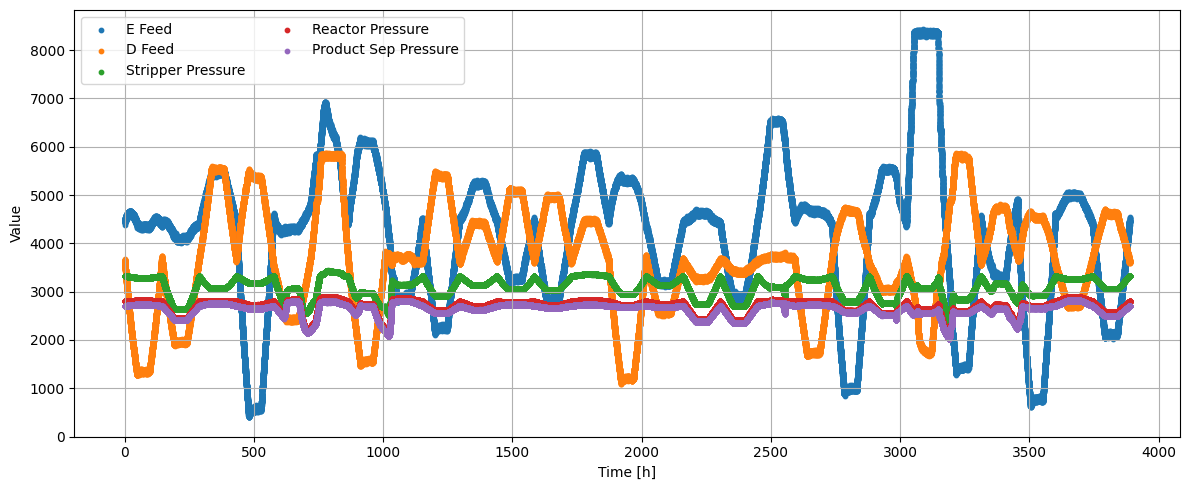

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

for col in top_n_by_var:
    ax.scatter(train_data["time"], train_data.loc[:, col], label=col, s=10)

# Add vertical lines for reset points
for i, reset_idx in enumerate(error_reset_indices):
    ax.axvline(reset_idx, color='red', linestyle='--', alpha=0.6, label='reset' if i == 0 else "")

ax.set_xlabel("Time [h]")
ax.set_ylabel("Value")
# ax.set_title("Top-5 Outputs by Dynamic Range")
ax.grid(True)
ax.legend(loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

## Drift-Funktionen (C-Referenzimplementierung)

Kompiliert die Drift-C-Dateien zu Shared Libraries und visualisiert das Sägezahn-Driftsignal von IDV(29) (Struktur analog c[k], Periode 800 h, IDV-Wert = Amplitude) sowie die Dreieck-Alternative ohne Sudden Drifts. In `temexd_mod_drift.c` wird die Variante über die `#include`-Zeile gewählt; dieselben C-Dateien liefern hier und im Simulator identische Verläufe.

In [38]:
import glob
import os
import pathlib
import shutil
import subprocess
import sys

drift_srcs = [base_dir / "src" / "drift_function_sawtooth.c",
              base_dir / "src" / "drift_function_triangle.c"]

_gcc = r"C:\msys64\ucrt64\bin\gcc.exe"
if _gcc is None:
    raise RuntimeError("Kein C-Compiler gefunden (gcc/MinGW).")
print("Compiler:", _gcc)
_env = os.environ.copy()
_env["PATH"] = os.path.dirname(_gcc) + os.pathsep + _env.get("PATH", "")

drift_libs = {}
for _src in drift_srcs:
    _lib = _src.with_suffix(".dll" if sys.platform == "win32" else ".so")
    _cmd = [_gcc, "-O2", "-shared", "-DDRIFT_BUILD_DLL", "-o", str(_lib), str(_src)]
    _res = subprocess.run(_cmd, capture_output=True, text=True, cwd=_src.parent, env=_env)
    if _res.returncode != 0:
        raise RuntimeError(f"Kompilierung fehlgeschlagen (Returncode {_res.returncode}):\n"
                           f"{_res.stdout}\n{_res.stderr}")
    drift_libs[_src.stem] = _lib
    print(f"Kompiliert -> {_lib.name}")

Compiler: C:\msys64\ucrt64\bin\gcc.exe
Kompiliert -> drift_function_sawtooth.dll
Kompiliert -> drift_function_triangle.dll


In [39]:
import ctypes

import numpy as np

def _bind(lib_path):
    lib = ctypes.CDLL(str(lib_path))
    lib.drift_signal.restype = ctypes.c_double
    lib.drift_signal.argtypes = [ctypes.c_double, ctypes.c_double,
                                 ctypes.c_double, ctypes.c_ulonglong]
    return lib

_saw = _bind(drift_libs["drift_function_sawtooth"])
_tri = _bind(drift_libs["drift_function_triangle"])

def _eval(lib, t, amplitude, period, gamma, seed):
    return amplitude * np.array([lib.drift_signal(float(x), period, gamma, seed)
                                 for x in np.atleast_1d(t)])

def drift_sawtooth(t, amplitude: float = ERROR_VARIANT_AMP,
                   period: float = DRIFT_PERIOD, gamma: float = DRIFT_GAMMA,
                   seed: int = DRIFT_SEED) -> np.ndarray:
    """Saegezahn analog c[k]; entspricht IDV(29) = amplitude (t in h).
    Parameter identisch zu den #defines in temexd_mod.c."""
    return _eval(_saw, t, amplitude, period, gamma, seed)

def drift_triangle(t, amplitude: float = ERROR_VARIANT_AMP,
                   period: float = DRIFT_PERIOD) -> np.ndarray:
    """Dreieck ohne Sudden Drifts (Austausch-Alternative)."""
    return _eval(_tri, t, amplitude, period, 0.0, 0)

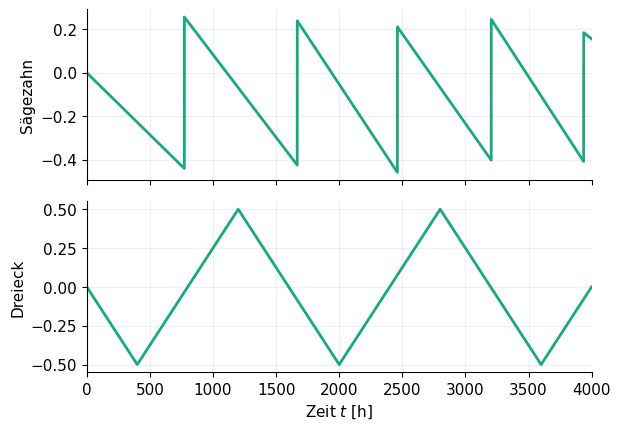

In [40]:
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

t = np.linspace(0.0, T_TOTAL, 8001)
fig, axes = plt.subplots(2, 1, figsize=(ts.fig_width(), ts.fig_width(0.7)), sharex=True)
for ax, (f, name) in zip(axes, [(drift_sawtooth, "Sägezahn"),
                                (drift_triangle, "Dreieck")]):
    ax.plot(t, f(t, amplitude=ERROR_VARIANT_AMP), **ts.line("drift_signal"))
    ax.set_ylabel(name)
    ax.grid(True, alpha=0.2)
    ax.margins(x=0)
axes[-1].set_xlabel("Zeit $t$ [h]")
plt.tight_layout()
plot_store.save_figure(plt.gcf(), "cd", cfg, final=IS_FINAL)
plt.show()

In [ ]:
## Zulaessiger Amplitudenbereich IDV(29)
# Ein Betriebspunkt (Mode 1), einzige Variable ist die IDV(29)-Amplitude.
# Periode/Gamma/Seed sind #defines in temexd_mod.c und hier bewusst fix.

SWEEP_AMPS = np.round(np.arange(0.05, 0.65, 0.05), 2)
SWEEP_HORIZON = 1600.0   # h: 1. Abstieg + 1. Sudden Drift
SWEEP_CHUNK = 25.0       # h: Aufloesung der Abbruchzeit

def probe_amplitude(si, amplitude, horizon=SWEEP_HORIZON, chunk=SWEEP_CHUNK):
    si.reset()
    si.set_idv(idv_idx=ERROR_VARIANT_ID, value=float(amplitude))
    t, status = 0.0, "paused"
    while t < horizon:
        si.simulate(chunk)
        t += chunk
        status = si._matlab_bridge.get_sim_status()
        if status == "stopped":
            break
    pdata = si._process_data
    t_end = float(pdata["time"].iloc[-1])
    t_stop = t_end if status == "stopped" else np.nan
    row = {"amp": float(amplitude), "status": status,
           "t_stop": t_stop, "t_end": t_end,
           "violation": next(iter(check_limits(si, limits)), None),
           "driftf_end": float(1.0 + drift_sawtooth(t_end, amplitude=amplitude)[0]),
           "driftf_min": float(1.0 + drift_sawtooth(
               np.linspace(0.0, t_end, 2001), amplitude=amplitude).min())}
    row.update({f"max {k}": float(pdata[k].max()) for k in limits})
    row.update({f"min {k}": float(pdata[k].min()) for k in limits})
    return row

_sweep_loaded_from_cache = data_store.exists("data_drift_sweep", cfg) and not FORCE_RECOMPUTE
if _sweep_loaded_from_cache:
    drift_sweep = data_store.load("data_drift_sweep", cfg, rename=True)
else:
    drift_sweep = pd.DataFrame([probe_amplitude(si, a) for a in SWEEP_AMPS])
    drift_sweep.attrs = {**run_cfg, "horizon": SWEEP_HORIZON, "chunk": SWEEP_CHUNK}
    data_store.save(drift_sweep, "data_drift_sweep", cfg)
drift_sweep

In [ ]:
# Analytische Grenze: Kinetikordnungen aus temexd_mod.c (c_b73, c_b74, ppr[3])
_n_ord = 1.1544 + 0.3735 + 1.0
_ptr = lambda kpag: 760.0 * (kpag / 101.325 + 1.0)
A_CRIT = {name: 2.0 * (1.0 - (_ptr(p) / _ptr(2800.0)) ** (-_n_ord))
          for name, p in [("isd=1 (3000 kPag)", 3000.0), ("Warnschwelle (2895)", 2895.0)]}

ok = drift_sweep.loc[drift_sweep["status"] != "stopped", "amp"]
print("A_crit analytisch:", {k: round(v, 3) for k, v in A_CRIT.items()})
print("A_crit empirisch :", float(ok.max()) if len(ok) else "keine Amplitude stabil")
print(drift_sweep.loc[drift_sweep["status"] == "stopped",
                      ["amp", "t_stop", "driftf_end", "violation"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(ts.fig_width(), ts.fig_width(0.45)))
ax.plot(drift_sweep["amp"], drift_sweep["max Reactor Pressure"], "o-")
ax.axhline(3000, ls="--", lw=0.8, label="Shutdown isd=1")
ax.axhline(limits["Reactor Pressure"], ls=":", lw=0.8, label="Warnschwelle")
for name, a in A_CRIT.items():
    ax.axvline(a, ls="--", lw=0.8, alpha=0.5)
ax.scatter(drift_sweep.loc[drift_sweep["status"] == "stopped", "amp"],
           drift_sweep.loc[drift_sweep["status"] == "stopped", "max Reactor Pressure"],
           marker="x", s=60, zorder=3, label="Shutdown")
ax.set_xlabel("IDV(29)-Amplitude $A$")
ax.set_ylabel("max. Reaktordruck [kPag]")
ax.grid(True, alpha=0.2); ax.legend()
plt.tight_layout()
plot_store.save_figure(plt.gcf(), "cd_amp_sweep", cfg, final=IS_FINAL)
plt.show()

## Lauf abgeschlossen

Zeigt die Kennungen dieses Laufs in einem Fenster mit Kopier-Button (Konsolenausgabe, falls keine GUI verfuegbar ist).

In [41]:
from src.utils.dialogs import show_with_copy_button

show_with_copy_button(
    "Lauf abgeschlossen",
    f"Datensynthese beendet.\n"
    f"Data Run-ID: {run_id}\n"
    f"Fehlerfall (IDV {ERROR_VARIANT_ID}, amp {ERROR_VARIANT_AMP}): {error_cfg.id}",
    copy_value=run_id,
)


--- Lauf abgeschlossen ---
Datensynthese beendet.
Data Run-ID: 58a387b8
Fehlerfall (IDV 29, amp 1.0): fedcacf7

